# 02 - Task 1: Restaurant Rating Regression

Predict `Aggregate rating` with strict leakage prevention and reproducible evaluation.

Leakage policy is defined in Notebook 01 and enforced here with anti-leakage assertions.

In [1]:
# Shared setup
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings('ignore')

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('seed:', SEED)

pandas: 2.2.3
numpy: 2.0.2
seed: 42


In [2]:
DATA_PATH = 'Dataset .csv'
df_raw = pd.read_csv(DATA_PATH)

EXPECTED_COLUMNS = [
    'Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
    'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
    'Average Cost for two', 'Currency', 'Has Table booking',
    'Has Online delivery', 'Is delivering now', 'Switch to order menu',
    'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes'
]
missing = sorted(set(EXPECTED_COLUMNS) - set(df_raw.columns))
assert not missing, f'Missing required columns: {missing}'
print('Loaded shape:', df_raw.shape)

Loaded shape: (9551, 21)


In [3]:
LEAKAGE_COLUMNS = ['Rating color', 'Rating text']
UNIVERSAL_DROP_COLUMNS = [
    'Restaurant ID', 'Restaurant Name', 'Address', 'Locality', 'Locality Verbose',
    'Longitude', 'Latitude', 'Switch to order menu'
]
YES_NO_COLUMNS = ['Has Table booking', 'Has Online delivery', 'Is delivering now']

def map_yes_no(series: pd.Series) -> pd.Series:
    mapping = {'Yes': 1, 'No': 0}
    return series.map(mapping).fillna(series)

def cuisine_tokens(value):
    if pd.isna(value):
        return ['Unknown']
    tokens = [x.strip() for x in str(value).split(',') if x.strip()]
    return tokens if tokens else ['Unknown']

def primary_cuisine(value):
    return cuisine_tokens(value)[0]

def apply_shared_preprocessing(df: pd.DataFrame, task: str) -> pd.DataFrame:
    out = df.copy()

    for c in YES_NO_COLUMNS:
        if c in out.columns:
            out[c] = map_yes_no(out[c])

    if task in {'task1', 'task2'}:
        out['Cuisines'] = out['Cuisines'].fillna('Unknown')
    elif task == 'task3':
        out = out.dropna(subset=['Cuisines']).copy()

    out['Cuisine Tokens'] = out['Cuisines'].apply(cuisine_tokens)
    out['Primary Cuisine'] = out['Cuisines'].apply(primary_cuisine)

    drop_cols = [c for c in UNIVERSAL_DROP_COLUMNS if c in out.columns]
    out = out.drop(columns=drop_cols)
    return out

In [4]:
df = apply_shared_preprocessing(df_raw, task='task1')

target_col = 'Aggregate rating'
feature_cols = [
    'Country Code', 'City', 'Primary Cuisine', 'Average Cost for two', 'Currency',
    'Has Table booking', 'Has Online delivery', 'Is delivering now',
    'Price range', 'Votes'
]

X = df[feature_cols].copy()
y = df[target_col].copy()

forbidden = set(LEAKAGE_COLUMNS + [target_col])
present_forbidden = sorted(forbidden.intersection(X.columns))
assert not present_forbidden, f'Leakage detected in X: {present_forbidden}'
assert target_col not in X.columns, 'Target leaked into feature matrix.'
print('Anti-leakage assertions passed.')

Anti-leakage assertions passed.


In [5]:
categorical_features = ['City', 'Primary Cuisine', 'Currency']
numeric_features = [
    'Country Code', 'Average Cost for two', 'Has Table booking',
    'Has Online delivery', 'Is delivering now', 'Price range', 'Votes'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=SEED, max_depth=12, min_samples_leaf=5)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({'Model': name, 'MSE': mse, 'R2': r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
display(results_df)

,Model,MSE,R2
0,DecisionTreeRegressor,0.112555,0.950549
1,LinearRegression,1.460935,0.358144


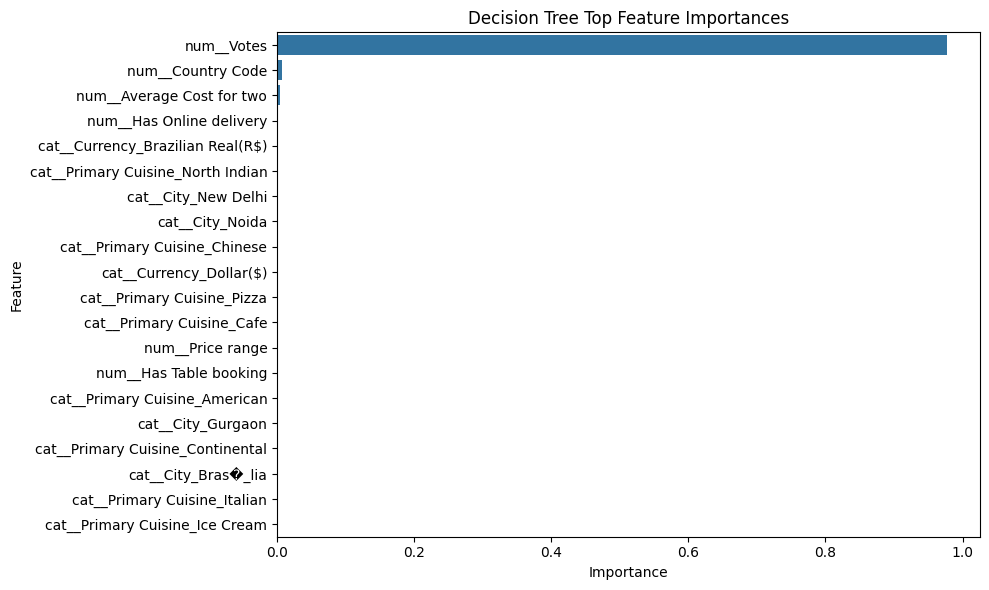

,Feature,Importance
263,num__Votes,0.976676
257,num__Country Code,0.007519
258,num__Average Cost for two,0.003825
260,num__Has Online delivery,0.001465
246,cat__Currency_Brazilian Real(R$),0.001449
205,cat__Primary Cuisine_North Indian,0.001283
80,cat__City_New Delhi,0.001262
81,cat__City_Noida,0.000746
154,cat__Primary Cuisine_Chinese,0.000723
247,cat__Currency_Dollar($),0.000708


In [6]:
best_tree = fitted_pipelines['DecisionTreeRegressor']
feature_names = best_tree.named_steps['prep'].get_feature_names_out()
importances = best_tree.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', orient='h')
plt.title('Decision Tree Top Feature Importances')
plt.tight_layout()
plt.show()

display(imp_df.head(10))

In [7]:
best_r2 = results_df['R2'].max()
print(f'Best R2: {best_r2:.4f}')

if best_r2 > 0.5:
    print('Baseline expectation met: R2 > 0.5')
else:
    print('Baseline expectation not met: R2 <= 0.5')
    print('Possible reasons: high noise in ratings, limited behavioral features, or strong location bias.')

Best R2: 0.9505
Baseline expectation met: R2 > 0.5
